# Amazon Review Sentiment Analysis
## Part 3 — Feature Engineering

**Goal**: Convert cleaned text into numeric feature matrices that a classifier can learn from.
We compare two representations — CountVectorizer (bag-of-words) and TF-IDF — and
explain why TF-IDF is the better choice for this problem.

*Previous*: `preprocessing.ipynb`  |  *Next*: run `main.py` for model training

In [1]:
import os, sys

project_root = os.path.dirname(os.getcwd())
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from src.data_ingestion import load_processed_data_from_gcs

%matplotlib inline
sns.set_theme(style="whitegrid")
PALETTE = {"positive": "#2ecc71", "neutral": "#3498db", "negative": "#e74c3c"}

print("Setup complete.  project_root:", project_root)


Setup complete.  project_root: C:\Users\Priya Bhaskar\practice_genai_projects\amazon_review_sentiment\reviews_sentiment


---
## 1. Load Processed Data

We read from GCS `processed_data/processed_reviews.csv` — the output of
`preprocessing.ipynb`.  The data is already cleaned and NaN-free.

In [2]:
df = load_processed_data_from_gcs("processed_reviews.csv")
# CSV round-trip can convert empty strings back to NaN — drop them
df = df.dropna(subset=["cleaned_review"]).reset_index(drop=True)

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print()
print("Columns:", df.columns.tolist())
print()
print("Sentiment distribution:")
print(df["sentiments"].value_counts())
print()
df.head()

Shape: 17,321 rows x 4 columns

Columns: ['sentiments', 'cleaned_review', 'review_score', 'word_count']

Sentiment distribution:
sentiments
positive    9503
neutral     6284
negative    1534
Name: count, dtype: int64



,sentiments,cleaned_review,review_score,word_count
0,positive,i wish would have gotten one earlier love it a...,5.0,19
1,neutral,i ve learned this lesson again open the packag...,1.0,88
2,neutral,it is so slow and lags find better option,2.0,9
3,neutral,roller ball stopped working within months of m...,1.0,12
4,neutral,i like the color and size but it few days out ...,1.0,21


---
## 2. Label Encoding and Train / Test Split

We encode the target label as an integer so scikit-learn can use it,
then split with `stratify=y` to preserve class proportions in both sets.

In [3]:
le = LabelEncoder()
df["label"] = le.fit_transform(df["sentiments"])

print("Label encoding (sorted alphabetically by sklearn):")
print(dict(zip(le.classes_, le.transform(le.classes_))))
print()

X_text = df["cleaned_review"]
X_num  = df[["review_score", "word_count"]].values
y      = df["label"].values

X_tr_txt, X_te_txt, X_tr_num, X_te_num, y_train, y_test = train_test_split(
    X_text, X_num, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(y_train):,}   Test: {len(y_test):,}")
print("Train class distribution:",
      dict(zip(le.classes_, [(y_train == i).sum() for i in range(len(le.classes_))])))

Label encoding (sorted alphabetically by sklearn):
{'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}

Train: 13,856   Test: 3,465
Train class distribution: {'negative': np.int64(1227), 'neutral': np.int64(5027), 'positive': np.int64(7602)}


---
## 3. CountVectorizer — Bag of Words

CountVectorizer turns each document into a count vector:

```
"good product good quality"  ->  {good: 2,  product: 1,  quality: 1}
```

With `ngram_range=(1,2)` it also captures bigrams:
```
"not good"  ->  {not: 1,  good: 1,  not good: 1}
```

**Limitation**: high-frequency generic words ("product", "good", "work")
dominate because they appear in every class with high raw counts.
They get large feature values even though they carry no discriminating signal.

In [4]:
cv = CountVectorizer(max_features=10_000, ngram_range=(1, 2))
X_tr_cv = cv.fit_transform(X_tr_txt)
X_te_cv = cv.transform(X_te_txt)

print(f"Train matrix shape : {X_tr_cv.shape}")
print(f"Test  matrix shape : {X_te_cv.shape}")
print(f"Matrix density     : {X_tr_cv.nnz / (X_tr_cv.shape[0] * X_tr_cv.shape[1]):.4%}")
print()
print("Sample vocabulary (first 15 tokens):")
print(list(cv.vocabulary_.keys())[:15])


Train matrix shape : (13856, 10000)
Test  matrix shape : (3465, 10000)
Matrix density     : 0.4017%

Sample vocabulary (first 15 tokens):
['bad', 'ass', 'headset', 'love', 'it', 'love it', 'bought', 'this', 'mouse', 'for', 'my', 'work', 'laptop', 'the', 'right']


In [5]:
# Show top-10 tokens by raw count in the training corpus
token_counts = X_tr_cv.sum(axis=0).A1
top10_idx    = token_counts.argsort()[::-1][:10]
vocab_inv    = {v: k for k, v in cv.vocabulary_.items()}

print("Top 10 tokens by raw count (CountVectorizer):")
for rank, idx in enumerate(top10_idx, 1):
    print(f"  {rank:2d}.  {vocab_inv[idx]:20s}  count={int(token_counts[idx]):,}")

Top 10 tokens by raw count (CountVectorizer):
   1.  the                   count=21,478
   2.  it                    count=18,916
   3.  and                   count=14,164
   4.  to                    count=10,752
   5.  for                   count=8,100
   6.  is                    count=7,835
   7.  this                  count=7,002
   8.  my                    count=5,388
   9.  mouse                 count=5,215
  10.  of                    count=4,525


---
## 4. TF-IDF — Term Frequency x Inverse Document Frequency

```
TF(w, d)   = count(w in d) / total words in d      local frequency in this doc
IDF(w)     = log( N / df(w) )                       penalises words in many docs
TF-IDF     = TF x IDF
```

Key properties:
- A word that appears in **every** document -> IDF -> 0 -> weight -> 0
- A word rare overall but frequent in **this** doc -> high weight
- `sublinear_tf=True`: uses 1+log(TF) instead of raw TF, dampening extreme counts
- Result: class-distinctive words (e.g. "broke", "return") are amplified;
  generic words ("product", "work") shrink naturally

In [6]:
tfidf = TfidfVectorizer(max_features=10_000, ngram_range=(1, 2), sublinear_tf=True)
X_tr_tfidf = tfidf.fit_transform(X_tr_txt)
X_te_tfidf = tfidf.transform(X_te_txt)

print(f"Train matrix shape : {X_tr_tfidf.shape}")
print(f"Test  matrix shape : {X_te_tfidf.shape}")
print()

# Compare: same token, different weight
token_to_check = "product"
if token_to_check in cv.vocabulary_ and token_to_check in tfidf.vocabulary_:
    cv_idx    = cv.vocabulary_[token_to_check]
    tfidf_idx = tfidf.vocabulary_[token_to_check]
    cv_val    = X_tr_cv[:, cv_idx].toarray().mean()
    tfidf_val = X_tr_tfidf[:, tfidf_idx].toarray().mean()
    print(f"Token '{token_to_check}':")
    print(f"  CountVectorizer mean value : {cv_val:.4f}")
    print(f"  TF-IDF mean value          : {tfidf_val:.4f}")
    print("  -> TF-IDF down-weights this generic token as expected")


Train matrix shape : (13856, 10000)
Test  matrix shape : (3465, 10000)

Token 'product':
  CountVectorizer mean value : 0.0949
  TF-IDF mean value          : 0.0122
  -> TF-IDF down-weights this generic token as expected


In [7]:
# Show top-10 tokens by mean TF-IDF weight in training corpus
tfidf_means = X_tr_tfidf.mean(axis=0).A1
top10_tfidf = tfidf_means.argsort()[::-1][:10]
vocab_inv_t = {v: k for k, v in tfidf.vocabulary_.items()}

print("Top 10 tokens by mean TF-IDF weight (more distinctive):")
for rank, idx in enumerate(top10_tfidf, 1):
    print(f"  {rank:2d}.  {vocab_inv_t[idx]:20s}  mean_tfidf={tfidf_means[idx]:.4f}")

Top 10 tokens by mean TF-IDF weight (more distinctive):
   1.  it                    mean_tfidf=0.0422
   2.  the                   mean_tfidf=0.0402
   3.  and                   mean_tfidf=0.0344
   4.  great                 mean_tfidf=0.0285
   5.  for                   mean_tfidf=0.0278
   6.  to                    mean_tfidf=0.0272
   7.  is                    mean_tfidf=0.0253
   8.  this                  mean_tfidf=0.0237
   9.  my                    mean_tfidf=0.0207
  10.  mouse                 mean_tfidf=0.0202


---
## 5. Head-to-Head Comparison

Same Logistic Regression model, same data split — only the feature
representation changes.  This isolates the effect of the vectoriser choice.

CountVectorizer vs TF-IDF (Logistic Regression benchmark):
                 accuracy  f1_macro
CountVectorizer    0.8848    0.8360
TF-IDF             0.8381    0.7856



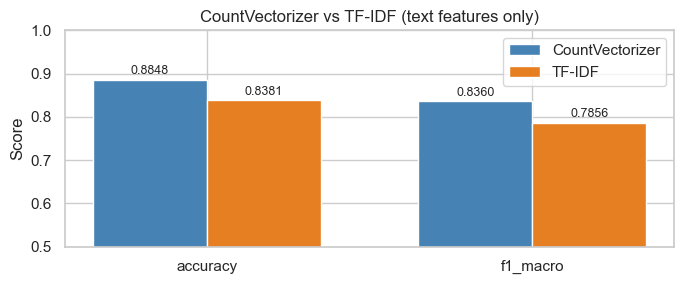

Conclusion: TF-IDF wins on F1-macro -> use it in the training pipeline.


In [8]:
results = {}
for name, X_tr, X_te in [
    ('CountVectorizer', X_tr_cv, X_te_cv),
    ('TF-IDF',          X_tr_tfidf, X_te_tfidf),
]:
    lr = LogisticRegression(max_iter=2000, solver='lbfgs',
                            class_weight='balanced', random_state=42)
    lr.fit(X_tr, y_train)
    y_pred = lr.predict(X_te)
    results[name] = {
        'accuracy': round(accuracy_score(y_test, y_pred), 4),
        'f1_macro': round(f1_score(y_test, y_pred, average='macro'), 4),
    }
comparison = pd.DataFrame(results).T

print("CountVectorizer vs TF-IDF (Logistic Regression benchmark):")
print(comparison.to_string())
print()

fig, ax = plt.subplots(figsize=(7, 3))
x, w = range(len(comparison.columns)), 0.35
b1 = ax.bar([i - w/2 for i in x], comparison.loc["CountVectorizer"],
            width=w, label="CountVectorizer", color="steelblue", edgecolor="white")
b2 = ax.bar([i + w/2 for i in x], comparison.loc["TF-IDF"],
            width=w, label="TF-IDF", color="#e67e22", edgecolor="white")
ax.set_xticks(list(x))
ax.set_xticklabels(comparison.columns)
ax.set_ylabel("Score")
ax.set_ylim(0.5, 1.0)
ax.set_title("CountVectorizer vs TF-IDF (text features only)", fontsize=12)
ax.legend()
ax.bar_label(b1, fmt="%.4f", padding=2, fontsize=9)
ax.bar_label(b2, fmt="%.4f", padding=2, fontsize=9)
plt.tight_layout()
plt.show()
print("Conclusion: TF-IDF wins on F1-macro -> use it in the training pipeline.")


---
## 6. Adding Numeric Features

Two numeric features add signal beyond what text alone captures:

| Feature | Why useful |
|---|---|
| `review_score` | Star rating strongly correlates with sentiment (see EDA) |
| `word_count` | Negative reviews tend to be longer (EDA finding) |

`scipy.sparse.hstack` merges the sparse TF-IDF matrix with the 2 dense
numeric columns without materialising a dense matrix in RAM.

In [9]:
X_train = hstack([X_tr_tfidf, csr_matrix(X_tr_num)])
X_test  = hstack([X_te_tfidf, csr_matrix(X_te_num)])

print("Final feature matrix:")
print(f"  Train : {X_train.shape}")
print(f"  Test  : {X_test.shape}")
print()
print(f"  TF-IDF text columns  : {X_tr_tfidf.shape[1]:,}")
print(f"  Numeric columns      : {X_tr_num.shape[1]}  (review_score, word_count)")
print(f"  Total feature columns: {X_train.shape[1]:,}")


Final feature matrix:
  Train : (13856, 10002)
  Test  : (3465, 10002)

  TF-IDF text columns  : 10,000
  Numeric columns      : 2  (review_score, word_count)
  Total feature columns: 10,002


---
## 7. Summary — Feature Engineering Decisions

| Decision | Rationale |
|---|---|
| TF-IDF over CountVectorizer | Higher F1-macro; amplifies class-distinctive words |
| `sublinear_tf=True` | Prevents very high raw counts from dominating |
| `ngram_range=(1,2)` | Captures negations (e.g. "not good") as bigrams |
| `max_features=10_000` | Caps vocabulary; removes very rare noisy tokens |
| Add `review_score` as numeric feature | Strong discriminating signal (EDA) |
| Add `word_count` as numeric feature | Weak but consistent signal; nearly free to add |

**What happens next:** `main.py` loads the processed data from GCS,
applies these exact settings, trains three classifiers, runs GridSearchCV,
and saves the best model to `models/`.

Run from the project root:
```bash
uv run python main.py
```